# Diversidade e apoio socioeducativo — Agrupamento de Escolas Francisco de Arruda

**Escola TEIP (Território Educativo de Intervenção Prioritária)**, Ajuda, Lisboa.

Este notebook analisa dados anonimizados de **463 alunos** em **23 turmas** (5º ao 9º ano + PIEF),
recolhidos no âmbito do processo de atualização de dados para o sistema Inovar (jun-ago 2026).

Nenhum dado pessoal identificável (nomes, documentos, contactos) é usado nesta análise —
ver `src/anonymize.py` para a metodologia de anonimização completa.

In [1]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import matplotlib.pyplot as plt

import analysis as an
import style

style.apply_mpl_style()
df = an.load_data()
an.overview(df)

{'total_alunos': 463,
 'total_turmas': 23,
 'anos_escolaridade': ['5', '6', '7', '8', '9', 'PIEF 6', 'PIEF 9']}

## 1. Visão geral

Total de alunos: 463
Total de turmas: 23
Anos de escolaridade: 5, 6, 7, 8, 9, PIEF 6, PIEF 9


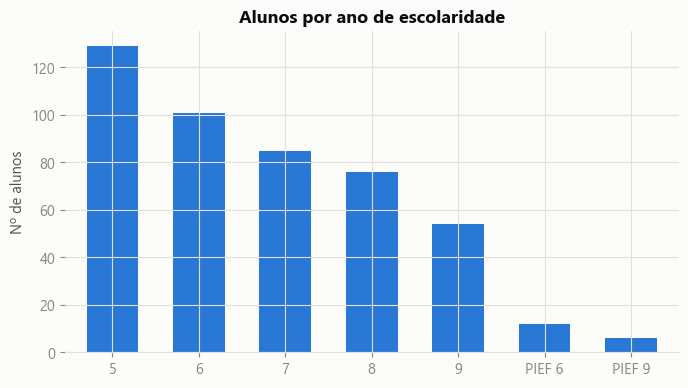

In [2]:
ov = an.overview(df)
print(f"Total de alunos: {ov['total_alunos']}")
print(f"Total de turmas: {ov['total_turmas']}")
print(f"Anos de escolaridade: {', '.join(ov['anos_escolaridade'])}")

df.groupby("ano_escolaridade").size().reindex(ov["anos_escolaridade"]).plot(
    kind="bar", figsize=(7, 4), color=style.CATEGORICAL[0], width=0.6
)
plt.title("Alunos por ano de escolaridade")
plt.xlabel("")
plt.ylabel("Nº de alunos")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 2. Fica na escola (atividades de tempos livres)

Muitos campos do formulário (ASE, RTP, PEI, PC/Internet, oferta de escola, religião,
autorização de saída) só são preenchidos para alunos que **ficam na escola** para
atividades de enriquecimento — confirmámos isto empiricamente (alunos que não ficam têm
estes campos em branco em ~90% dos casos). **Todas as secções seguintes que dependem
destes campos excluem os alunos que não ficam**, para não subestimar as taxas reais.

fica_escola
Sim    301
Não     97
N/A     65
Name: count, dtype: int64

fica_escola
Sim    65.0
Não    21.0
N/A    14.0
Name: count, dtype: float64


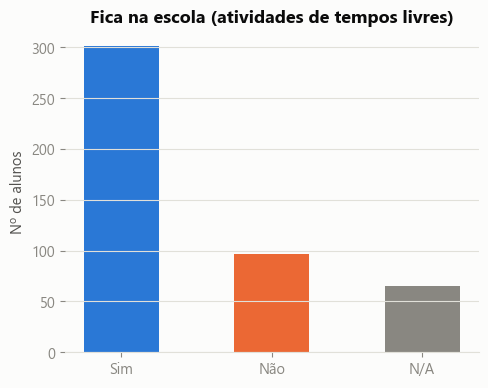

In [3]:
fica = an.fica_escola_breakdown(df)
print(fica)
print()
pct = (fica / fica.sum() * 100).round(1)
print(pct)

fig, ax = plt.subplots(figsize=(5, 4))
colors = [style.SIM, style.NAO, style.INK_MUTED]
ax.bar(fica.index, fica.values, color=colors[: len(fica)], width=0.5)
ax.set_ylabel("Nº de alunos")
ax.set_title("Fica na escola (atividades de tempos livres)")
plt.tight_layout()
plt.show()

## 3. Rácio Português vs. estrangeiro

Uma escola TEIP tipicamente serve populações mais diversas — o gráfico confirma isso.
Alunos sem nacionalidade registada (13.8%) são excluídos do rácio, para não distorcer a
proporção real (ver nota de qualidade de dados na secção final).

grupo_nacionalidade
Portuguesa     65.4
Estrangeira    34.6
Name: count, dtype: float64


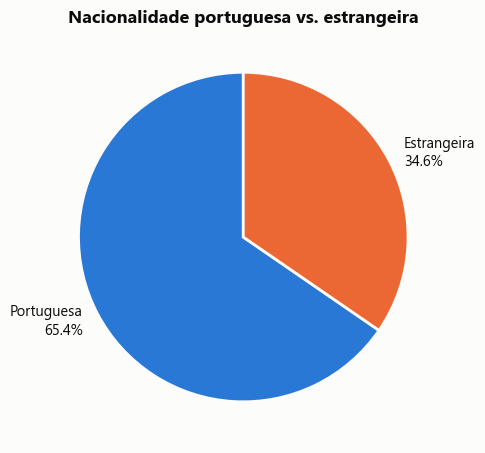

In [4]:
ratio = an.pt_vs_estrangeira(df)
pct = (ratio / ratio.sum() * 100).round(1)
print(pct)

colors = [style.PORTUGUESA, style.ESTRANGEIRA]
fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(ratio, labels=[f"{i}\n{p}%" for i, p in zip(ratio.index, pct)],
       colors=colors, startangle=90, wedgeprops={"linewidth": 2, "edgecolor": style.SURFACE})
ax.set_title("Nacionalidade portuguesa vs. estrangeira")
plt.tight_layout()
plt.show()

## 4. Nacionalidades representadas

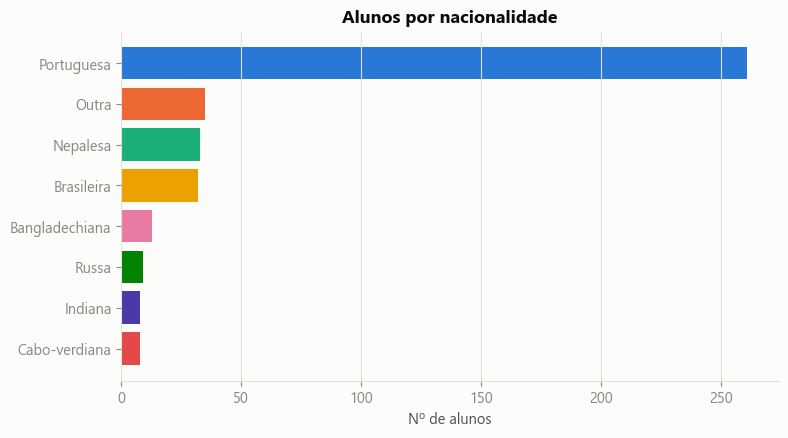

Índice de diversidade (Simpson): 0.553
(0 = uma só nacionalidade; quanto mais perto de 1, mais diversa a escola)


In [5]:
nat = an.nationality_breakdown(df, top_n=7)
colors = (style.CATEGORICAL * 2)[: len(nat)]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(nat.index[::-1], nat.values[::-1], color=colors[::-1])
ax.set_title("Alunos por nacionalidade")
ax.set_xlabel("Nº de alunos")
ax.grid(axis="x")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

print(f"Índice de diversidade (Simpson): {an.simpson_diversity_index(df)}")
print("(0 = uma só nacionalidade; quanto mais perto de 1, mais diversa a escola)")

## 5. Ação Social Escolar (ASE)

Quantos alunos requisitaram ASE — calculado apenas sobre alunos que ficam na escola
(ver secção 2), já que é aí que este campo é efetivamente preenchido.

{'Sim': {'n': 175, 'pct': np.float64(58.1)}, 'Não': {'n': 102, 'pct': np.float64(33.9)}, 'N/A': {'n': 24, 'pct': np.float64(8.0)}}


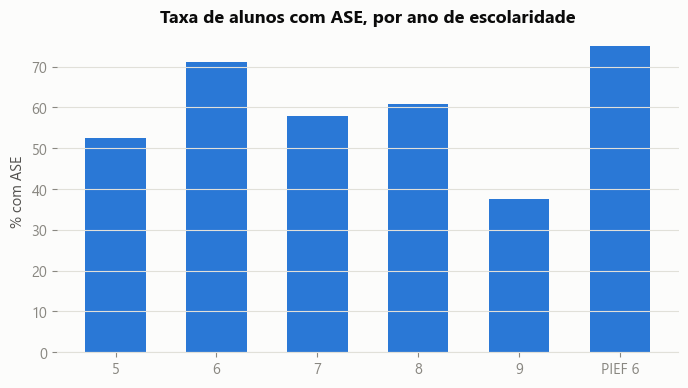


Taxa de ASE por grupo de nacionalidade:
                      ase
grupo_nacionalidade      
Estrangeira          38.8
Portuguesa           67.5


In [6]:
ase_counts = an.yn_overall_count(df, "ase")
print(ase_counts)

ase_by_year = an.rate_by_group(df, "ase")
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(ase_by_year.index, ase_by_year.values, color=style.CATEGORICAL[0], width=0.6)
ax.set_title("Taxa de alunos com ASE, por ano de escolaridade")
ax.set_ylabel("% com ASE")
plt.tight_layout()
plt.show()

print()
print("Taxa de ASE por grupo de nacionalidade:")
print(an.support_needs_by_nationality(df)[["ase"]])

## 6. Literacia digital: acesso a computador e internet em casa

Tem PC: {'Não': {'n': 164, 'pct': np.float64(54.5)}, 'Sim': {'n': 133, 'pct': np.float64(44.2)}, 'N/A': {'n': 4, 'pct': np.float64(1.3)}}
Tem Internet: {'Sim': {'n': 269, 'pct': np.float64(89.4)}, 'Não': {'n': 28, 'pct': np.float64(9.3)}, 'N/A': {'n': 4, 'pct': np.float64(1.3)}}


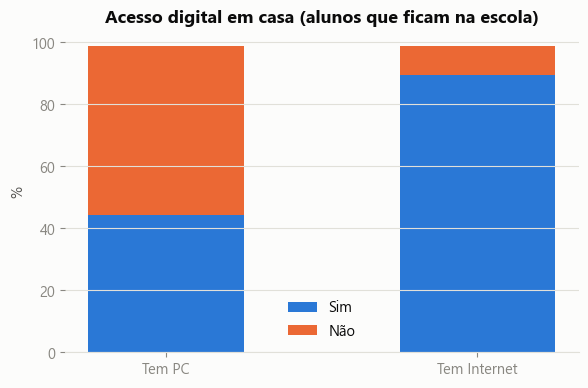

In [7]:
pc = an.yn_overall_count(df, "tem_pc")
net = an.yn_overall_count(df, "tem_internet")
print("Tem PC:", pc)
print("Tem Internet:", net)

fig, ax = plt.subplots(figsize=(6, 4))
labels = ["Tem PC", "Tem Internet"]
sim_vals = [pc.get("Sim", {}).get("pct", 0), net.get("Sim", {}).get("pct", 0)]
nao_vals = [pc.get("Não", {}).get("pct", 0), net.get("Não", {}).get("pct", 0)]
x = range(len(labels))
ax.bar(x, sim_vals, color=style.SIM, label="Sim", width=0.5)
ax.bar(x, nao_vals, bottom=sim_vals, color=style.NAO, label="Não", width=0.5)
ax.set_xticks(list(x), labels)
ax.set_ylabel("%")
ax.set_title("Acesso digital em casa (alunos que ficam na escola)")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## 7. Oferta de escola: escolhas de atividades

Contagem de cada atividade (Música / Teatro / Cenografia) por ordem de escolha
(1ª, 2ª, 3ª) e por ano de escolaridade, em número de alunos e percentagem.

In [8]:
geral = an.oferta_escola_counts(df, by_ano=False)
print(geral.to_string(index=False))

   escolha  atividade  contagem  percentagem
1ª escolha     Teatro       137         48.9
1ª escolha     Música       104         37.1
1ª escolha Cenografia        39         13.9
2ª escolha Cenografia       119         43.4
2ª escolha     Teatro        93         33.9
2ª escolha     Música        62         22.6
3ª escolha Cenografia       116         42.3
3ª escolha     Música       114         41.6
3ª escolha     Teatro        44         16.1


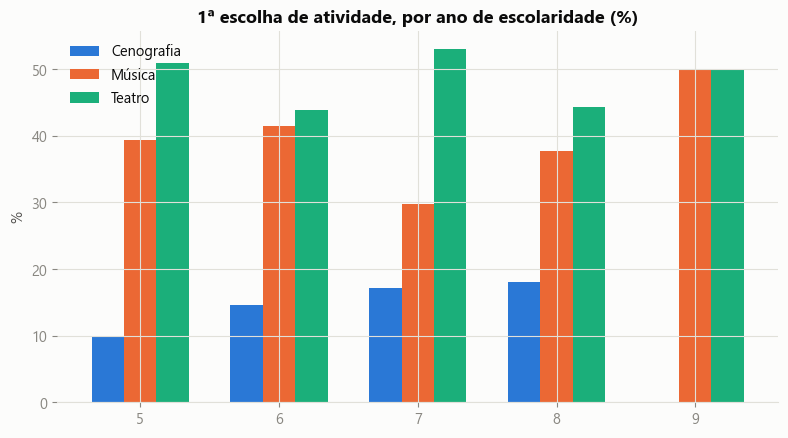

In [9]:
por_ano = an.oferta_escola_counts(df, by_ano=True)
primeira_escolha = por_ano[por_ano["escolha"] == "1ª escolha"]
pivot = primeira_escolha.pivot(index="ano_escolaridade", columns="atividade", values="percentagem").fillna(0)

fig, ax = plt.subplots(figsize=(8, 4.5))
pivot.plot(kind="bar", ax=ax, color=style.CATEGORICAL[:len(pivot.columns)], width=0.7)
ax.set_title("1ª escolha de atividade, por ano de escolaridade (%)")
ax.set_ylabel("%")
ax.set_xlabel("")
ax.legend(frameon=False, title="")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 8. Condições de saúde

Categorias amplas (nunca o diagnóstico literal) — ver metodologia de anonimização.
Categorias com menos de 3 alunos na escola são agrupadas em "Outra condição", para
não identificar indiretamente um aluno através de uma condição rara.

                                    contagem  percentagem
categoria_saude                                          
Nenhuma                                  286         81.0
Outra condição                            25          7.1
Respiratório (asma/bronquite)             17          4.8
Hiperatividade / défice de atenção        11          3.1
Neurológico                                6          1.7
Alergias                                   4          1.1
Hematológico                               4          1.1


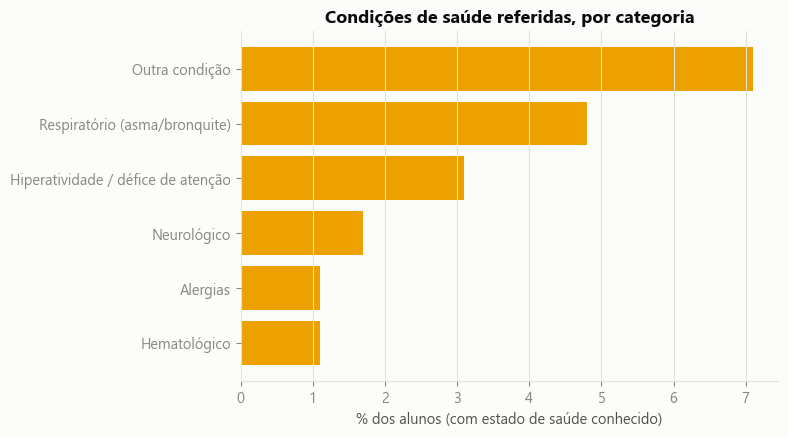


81.0% dos alunos com estado de saúde conhecido não têm nenhuma condição referida.


In [10]:
saude = an.health_condition_breakdown(df)
print(saude)

sem_nenhuma = saude.drop(index="Nenhuma", errors="ignore")
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(sem_nenhuma.index[::-1], sem_nenhuma["percentagem"].values[::-1], color=style.CATEGORICAL[3])
ax.set_xlabel("% dos alunos (com estado de saúde conhecido)")
ax.set_title("Condições de saúde referidas, por categoria")
ax.grid(axis="x")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

pct_sem_condicao = saude.loc["Nenhuma", "percentagem"] if "Nenhuma" in saude.index else None
print(f"\n{pct_sem_condicao}% dos alunos com estado de saúde conhecido não têm nenhuma condição referida.")

## 9. Restrições alimentares

                                             contagem  percentagem
categoria_restricao_alimentar                                     
Nenhuma                                           320         90.9
Não come porco/vaca (cultural ou religioso)        15          4.3
Alergia alimentar                                   9          2.6
Vegetariano                                         5          1.4
Outra restrição                                     3          0.9


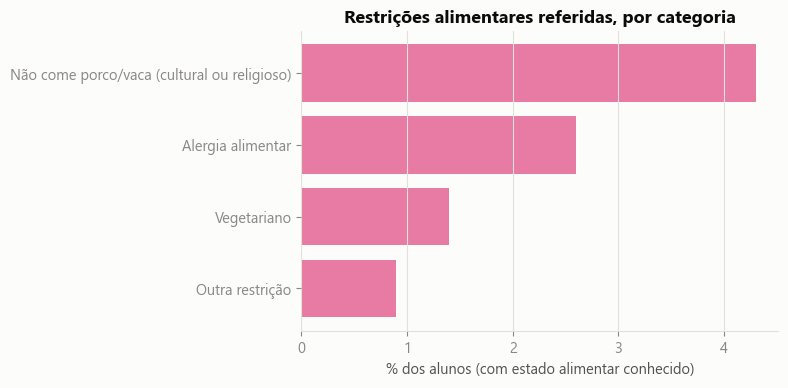

In [11]:
dieta = an.dietary_restriction_breakdown(df)
print(dieta)

sem_nenhuma = dieta.drop(index="Nenhuma", errors="ignore")
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(sem_nenhuma.index[::-1], sem_nenhuma["percentagem"].values[::-1], color=style.CATEGORICAL[4])
ax.set_xlabel("% dos alunos (com estado alimentar conhecido)")
ax.set_title("Restrições alimentares referidas, por categoria")
ax.grid(axis="x")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

## 10. PEI, RTP e Autorização de saída

In [12]:
for col, nome in [("pei", "PEI"), ("rtp", "RTP")]:
    counts = an.yn_overall_count(df, col)
    print(f"{nome}: {counts}")

print()
print("Autorização de saída (distribuição):")
print(an.autorizacao_saida_breakdown(df))

print()
print("Religião/moral (alunos que ficam na escola):")
print(an.religiao_breakdown(df))

PEI: {'Não': {'n': 265, 'pct': np.float64(88.0)}, 'Sim': {'n': 21, 'pct': np.float64(7.0)}, 'N/A': {'n': 15, 'pct': np.float64(5.0)}}
RTP: {'Não': {'n': 247, 'pct': np.float64(82.1)}, 'Sim': {'n': 44, 'pct': np.float64(14.6)}, 'N/A': {'n': 10, 'pct': np.float64(3.3)}}

Autorização de saída (distribuição):
autorizacao_saida
D             148
C              63
A              45
C, D           17
B               9
N/A             6
B, C, D         4
A, B, C, D      4
B, C            3
A, C, D         1
com o CCR       1
Name: count, dtype: int64

Religião/moral (alunos que ficam na escola):
religiao_moral
Nenhuma        250
EMRC            21
EMRE            17
N/A              9
EMRC e EMRE      4
Name: count, dtype: int64


## 11. Qualidade dos dados

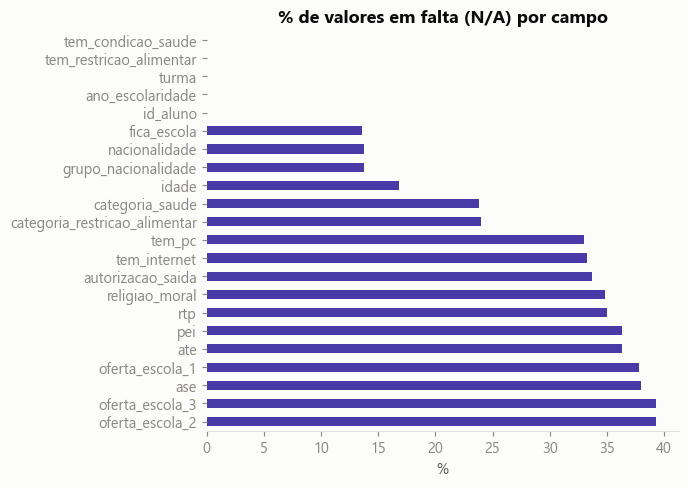

Nota: idade calculada só é fiável para 385 de 463 alunos — datas de nascimento em falta ou implausíveis na fonte


In [13]:
missing = an.missing_data_rates(df)
fig, ax = plt.subplots(figsize=(7, 5))
missing.plot(kind="barh", ax=ax, color=style.CATEGORICAL[6])
ax.set_title("% de valores em falta (N/A) por campo")
ax.set_xlabel("%")
ax.grid(axis="x")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

print("Nota: idade calculada só é fiável para", df['idade'].notna().sum(),
      "de", len(df), "alunos — datas de nascimento em falta ou implausíveis na fonte")

## Conclusões

- A escola serve uma população claramente diversa, com mais de 10 nacionalidades
  representadas e um rácio de cerca de 1 em cada 3 alunos de nacionalidade estrangeira
  (entre os que têm nacionalidade registada).
- Cerca de 65% dos alunos ficam na escola para atividades de tempos livres — a maioria
  dos campos de apoio só existe para este grupo, e as taxas nesta análise refletem isso.
- Entre os alunos que ficam na escola, a maioria requisita ASE — um sinal claro do
  perfil socioeconómico que justifica o estatuto TEIP do agrupamento.
- O acesso a internet em casa é consideravelmente mais alto do que o acesso a
  computador próprio — relevante para qualquer estratégia de ensino que dependa de
  dispositivos próprios.
- Teatro é a atividade mais escolhida em 1ª opção; a preferência muda para as
  escolhas seguintes, sugerindo que os alunos distribuem as suas 3 escolhas pelas
  atividades disponíveis em vez de repetir preferências.
- Cerca de 1 em cada 5 alunos com estado de saúde conhecido tem alguma condição
  referida, sobretudo respiratória (asma/bronquite) e défice de atenção/hiperatividade.
- A qualidade dos dados de origem tem lacunas relevantes (nacionalidade e data de
  nascimento em falta numa fração not-trivial dos registos) — uma oportunidade de
  melhoria de processo para o preenchimento no Inovar.